In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D Ising model with Metropolis updates and periodic boundaries
# ============================================================

# Critical coupling for the 2D square-lattice Ising model
BETA_J_C = np.log(1.0 + np.sqrt(2.0)) / 2.0


def betaJ_from_reduced_t(t):
    """
    Convert reduced temperature t = (T - Tc) / Tc into beta*J.

    Since T = Tc * (1 + t), we have
        beta*J = (beta*J)_c / (1 + t).
    """
    return BETA_J_C / (1.0 + t)


def initialize_lattice(L, rng, start="random"):
    """
    Create an L x L lattice of spins.

    Spins are either +1 or -1.
    """
    if start == "random":
        return rng.choice([-1, 1], size=(L, L)).astype(np.int8)

    if start == "up":
        return np.ones((L, L), dtype=np.int8)

    if start == "down":
        return -np.ones((L, L), dtype=np.int8)

    raise ValueError("start must be 'random', 'up', or 'down'")


def checkerboard_masks(L):
    """
    Make the two checkerboard sublattices.

    For an even L with periodic boundaries, no two sites on the same
    checkerboard sublattice are nearest neighbors. This lets us update
    many independent single-spin Metropolis proposals at once.

    input: array of shape (L, L) with values -1 or +1 representing the spin configuration
    output: two boolean arrays of shape (L, L) representing the black and white sublattices
    """
    if L % 2 != 0:
        raise ValueError("This checkerboard update assumes even L. Use L=64.")

    i, j = np.indices((L, L))

    black_sites = (i + j) % 2 == 0
    white_sites = (i + j) % 2 == 1

    return black_sites, white_sites


def neighbor_sum_periodic(spins):
    """
    Sum the four nearest neighbors of every site using periodic boundaries.

    np.roll wraps around the edges, so the top talks to the bottom and
    the left talks to the right.

    returns: array of shape (L, L) where each element is the sum of the four neighbors of the corresponding site in the input array
    """
    up    = np.roll(spins,  1, axis=0) # this shifts array down. so, each site gets the value of the site above it
    down  = np.roll(spins, -1, axis=0)
    left  = np.roll(spins,  1, axis=1)
    right = np.roll(spins, -1, axis=1)

    return up + down + left + right


def metropolis_sweep(spins, betaJ, h, rng, masks):
    """
    Perform one full Metropolis sweep. This updates every spin on a checkerboard sublattice since they are independent

    The effective dimensionless energy is

        E = - betaJ * sum_<ij> s_i s_j - h * sum_i s_i.

    Flipping one spin s_i changes this energy by

        dE = 2 * s_i * (betaJ * neighbor_sum + h).

    Metropolis rule:
        accept always if dE <= 0,
        otherwise accept with probability exp(-dE).
    """
    # Randomize whether black or white sites are updated first.
    # This is not strictly necessary, but it avoids a fixed update order.
    if rng.random() < 0.5:
        update_order = masks
    else:
        update_order = masks[::-1]

    for mask in update_order:
        # Compute nearest-neighbor sum with periodic boundary conditions
        nn = neighbor_sum_periodic(spins)

        # Energy change for flipping every spin
        dE = 2.0 * spins * (betaJ * nn + h) # this is an array of shape (L, L) with the energy change for flipping each spin

        # For dE <= 0, accept probability should be 1.
        # For dE > 0, accept probability is exp(-dE).
        accept_probability = np.exp(-np.maximum(dE, 0.0)) # this is an array of shape (L, L) with the acceptance probability for flipping each spin

        # Draw random numbers and accept flips only on the chosen sublattice
        accept = mask & (rng.random(spins.shape) < accept_probability) # this is a boolean array of shape (L, L) where True indicates that the spin flip is accepted for the corresponding site

        # Flip accepted spins
        spins[accept] *= -1


def magnetization(spins):
    """
    Magnetization per spin.
    """
    return np.mean(spins)


def energy_per_spin(spins, betaJ, h):
    """
    Dimensionless energy per spin.

    We count each nearest-neighbor bond once by using only the right
    and down neighbors.
    """
    right_bonds = spins * np.roll(spins, -1, axis=1) # this is an array of shape (L, L) where each element is the product of the spin at that site and the spin to its right
    down_bonds  = spins * np.roll(spins, -1, axis=0)

    bond_sum = np.sum(right_bonds + down_bonds)
    field_sum = np.sum(spins)

    E = -betaJ * bond_sum - h * field_sum

    return E / spins.size


def run_ising(
    L=64,
    t=0.05,
    h=0.0,
    n_sweeps=3000,
    measure_every=10,
    seed=None,
    start="random",
):
    """
    Run one Ising simulation.

    Parameters
    ----------
    L : int
        Lattice size. Assignment asks for L=64.
    t : float
        Reduced temperature, t = (T - Tc) / Tc.
    h : float
        Dimensionless magnetic field.
    n_sweeps : int
        Total number of sweeps.
    measure_every : int
        Save magnetization and energy every this many sweeps.
    seed : int
        Random seed for reproducibility.
    start : str
        'random', 'up', or 'down'.

    Returns
    -------
    result : dict
        Contains final spins, magnetization history, energy history, etc.
    """
    rng = np.random.default_rng(seed)

    betaJ = betaJ_from_reduced_t(t)

    spins = initialize_lattice(L, rng, start=start)

    masks = checkerboard_masks(L)

    m_history = []
    e_history = []
    sweep_history = []

    for sweep in range(n_sweeps):
        metropolis_sweep(spins, betaJ, h, rng, masks)

        if sweep % measure_every == 0:
            m_history.append(magnetization(spins))
            e_history.append(energy_per_spin(spins, betaJ, h))
            sweep_history.append(sweep)

    return {
        "spins": spins.copy(),
        "m": np.array(m_history),
        "E": np.array(e_history),
        "sweeps": np.array(sweep_history),
        "L": L,
        "t": t,
        "h": h,
        "betaJ": betaJ,
    }


def plot_spin_config(spins, title="", save_path=None):
    """
    Plot one spin configuration.

    White and black pixels correspond to the two spin values.
    """
    plt.figure(figsize=(4, 4))
    plt.imshow(spins, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_snapshot_grid(results, condition_order):
    """
    Plot the final lattice snapshot for each condition.
    """
    n = len(condition_order)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.8 * nrows))
    axes = np.ravel(axes)

    for ax, key in zip(axes, condition_order):
        result = results[key]
        spins = result["spins"]

        t = result["t"]
        h = result["h"]
        m_final = magnetization(spins)

        ax.imshow(spins, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
        ax.set_title(f"t={t:g}, h={h:g}\nfinal m={m_final:+.3f}")
        ax.axis("off")

    # Hide unused panels, if any
    for ax in axes[len(condition_order):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_magnetization_histories(results, condition_order):
    """
    Plot magnetization history for each simulation.
    """
    plt.figure(figsize=(8, 5))

    for key in condition_order:
        result = results[key]
        label = f"t={result['t']:g}, h={result['h']:g}"
        plt.plot(result["sweeps"], result["m"], label=label)

    plt.axhline(0, linewidth=1)
    plt.xlabel("Sweep after thermalization")
    plt.ylabel("Magnetization per spin")
    plt.title("Magnetization histories")
    plt.legend()
    plt.tight_layout()
    plt.show()


def safe_number_for_filename(x):
    """
    Turn numbers like 0.05 into strings like 0p05 for filenames.
    """
    return str(x).replace("-", "m").replace(".", "p")


def save_favorite_images(results, favorite_keys):
    """
    Save selected configurations as PNG images.

    At least one favorite should have h != 0 for the assignment.
    """
    saved_files = []

    for key in favorite_keys:
        result = results[key]

        t = result["t"]
        h = result["h"]
        L = result["L"]
        spins = result["spins"]

        filename = (
            f"ising_L{L}_t{safe_number_for_filename(t)}"
            f"_h{safe_number_for_filename(h)}.png"
        )

        title = f"2D Ising, L={L}, t={t:g}, h={h:g}"

        plot_spin_config(spins, title=title, save_path=filename)

        saved_files.append(filename)

    return saved_files

In [18]:
# ============================================================
# Run the assignment's requested simulations
# ============================================================

L = 64

# The condition (t=0.05, h=0) appears in both assignment lists,
# so we only need to run it once.
conditions = [
    (0.05, 0.0),
    (0.10, 0.0),
    (1.00, 0.0),
    (0.05, 0.001),
    (0.05, 0.01),
    (0.05, 0.10),
    (-0.05, 0.0),
    (-0.05, 0.01),
    (0, 0),
]

results = {}

for run_number, (t, h) in enumerate(conditions):
    print(f"Running L={L}, t={t:g}, h={h:g}...")

    result = run_ising(
        L=L,
        t=t,
        h=h,
        n_sweeps=2000,
        measure_every=10,
        seed=1234 + run_number,
        start="random",
    )

    results[(t, h)] = result

    print(
        f"  betaJ = {result['betaJ']:.5f}, "
        f"final m = {magnetization(result['spins']):+.4f}, "
        f"mean |m| = {np.mean(np.abs(result['m'])):.4f}"
    )

Running L=64, t=0.05, h=0...
  betaJ = 0.41970, final m = +0.1265, mean |m| = 0.0944
Running L=64, t=0.1, h=0...
  betaJ = 0.40062, final m = -0.2710, mean |m| = 0.0821
Running L=64, t=1, h=0...
  betaJ = 0.22034, final m = -0.0171, mean |m| = 0.0204
Running L=64, t=0.05, h=0.001...
  betaJ = 0.41970, final m = +0.2861, mean |m| = 0.3722
Running L=64, t=0.05, h=0.01...
  betaJ = 0.41970, final m = +0.6646, mean |m| = 0.6067
Running L=64, t=0.05, h=0.1...
  betaJ = 0.41970, final m = +0.8638, mean |m| = 0.8677
Running L=64, t=-0.05, h=0...
  betaJ = 0.46388, final m = -0.7954, mean |m| = 0.7597
Running L=64, t=-0.05, h=0.01...
  betaJ = 0.46388, final m = +0.8818, mean |m| = 0.8326
Running L=64, t=0, h=0...
  betaJ = 0.44069, final m = +0.6099, mean |m| = 0.4271


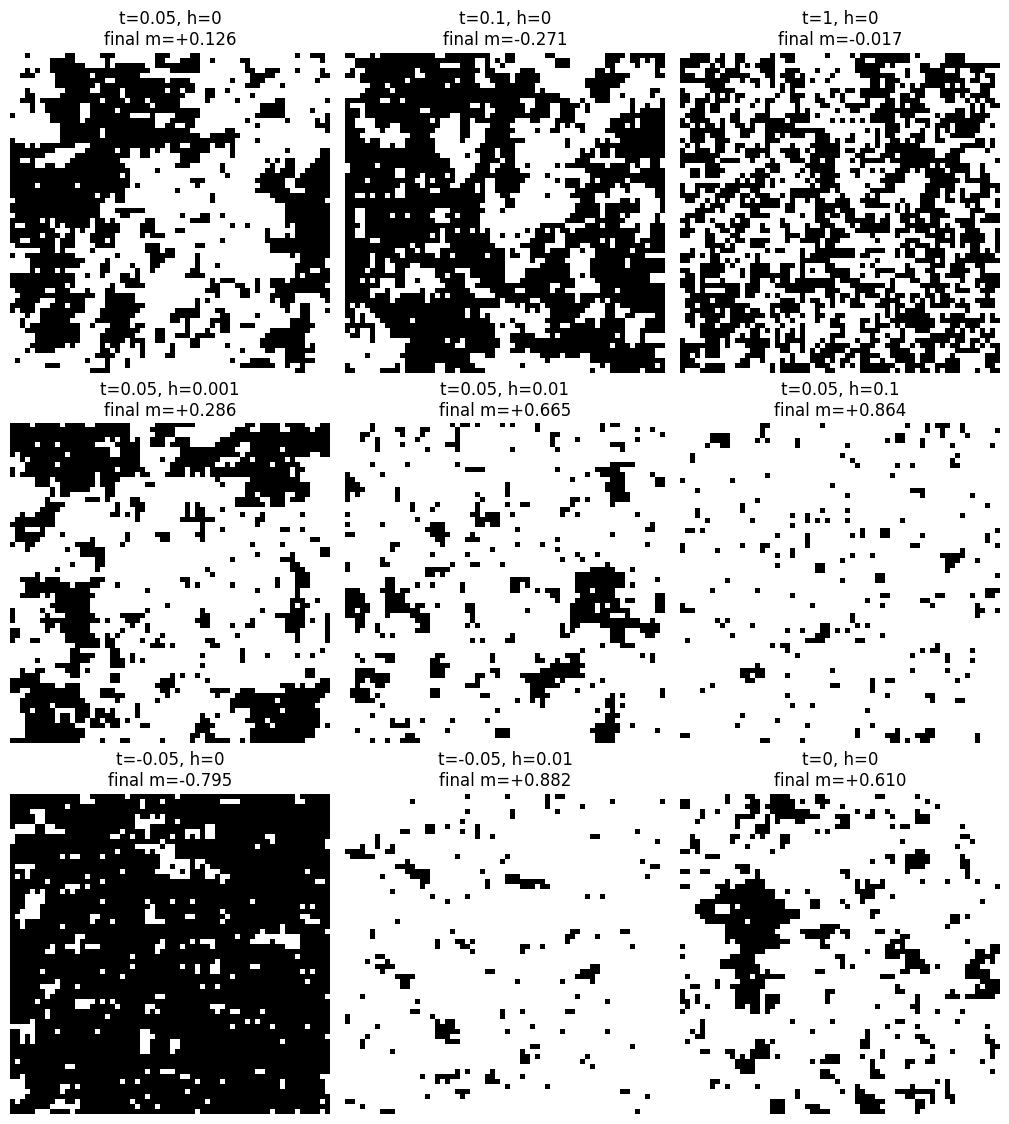

In [19]:
plot_snapshot_grid(results, conditions)

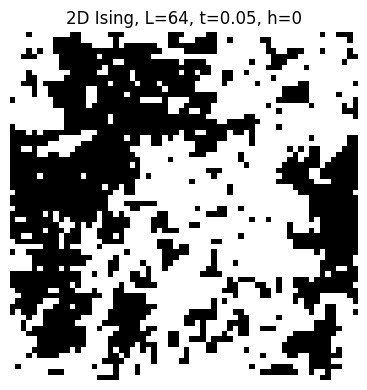

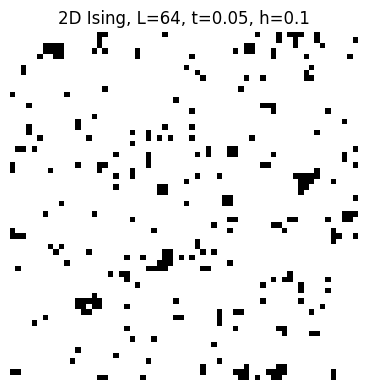

Saved image files:
ising_L64_t0p05_h0p0.png
ising_L64_t0p05_h0p1.png


In [21]:
favorite_keys = [
    (0.05, 0.0),
    (0.05, 0.1),
]

saved_files = save_favorite_images(results, favorite_keys)

print("Saved image files:")
for file in saved_files:
    print(file)